<a href="https://colab.research.google.com/github/cchen744/olist-regional-customer-experience-analysis/blob/main/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Feature Design
Features are divided into three categories.

Target variable:
- negative_review = review_score ≤ 2

(1) **Delivery performance (derived from timestamps)**
```code
delivery_days # delievered_time - ordered_time
late_delievery # wether an order is late delievered
delay_days # how long an order is delayed
```

(2) **Spatial features**
```code
same_state # (customer_location == seller_location) -> state level analysis
shipping_distance # |cutomer_location - seller_location| -> optional later
seller_density # this is important because higher seller density might cause more logistic burden.
```

(3) **Order & product features**
```code
price # total price of one single order
freight_ratio # freigh_value / price. Note that freight value is shipping cost.
product_category # optional for One-Hot encoding
num_items
```

## Library import

In [43]:
import os
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2
import numpy as np
import seaborn as sns
from google.colab import userdata
import statsmodels.api as sm

## Load datasets
Since it is not super convenient to merge all the dataset into one universal dataset (as it would be extremely big and hard to process), I am going to focus on subdatasets serving for seperate purposes (delievery performance, spatial features, order & product features).


In [44]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME') # Replace with username from json
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')           # Replace with key from json

from kaggle.api.kaggle_api_extended import KaggleApi

# 1. Authenticate
api = KaggleApi()
api.authenticate()

# 2. Download and Extract
# This handles the "extraction" part automatically with unzip=True
dataset_slug = "olistbr/brazilian-ecommerce"
download_path = "./brazilian_ecommerce_data"

print(f"Downloading {dataset_slug}...")
api.dataset_download_files(dataset_slug, path=download_path, unzip=True)
print("Download and extraction complete.\n")

# 3. Load the data using os.listdir
# The Olist dataset has multiple CSV files (orders, customers, products, etc.)
dataframes = {}

print("Loading files...")
for filename in os.listdir(download_path):
    if filename.endswith(".csv"):
        # Construct full file path
        file_path = os.path.join(download_path, filename)

        # Create a simpler name for the dataframe (e.g., "olist_orders_dataset.csv" -> "orders")
        # This is optional but makes accessing them easier
        df_name = filename.split('_dataset')[0].replace('olist_', '')

        # Load into dictionary
        dataframes[df_name] = pd.read_csv(file_path)
        print(f"--> Loaded {filename} as '{df_name}' (Shape: {dataframes[df_name].shape})")

# Example: Accessing one of the loaded tables
print("\nExample: First 5 rows of orders:")

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
Download and extraction complete.

Loading files...
--> Loaded olist_customers_dataset.csv as 'customers' (Shape: (99441, 5))
--> Loaded olist_order_payments_dataset.csv as 'order_payments' (Shape: (103886, 5))
--> Loaded olist_geolocation_dataset.csv as 'geolocation' (Shape: (1000163, 5))
--> Loaded olist_order_items_dataset.csv as 'order_items' (Shape: (112650, 7))
--> Loaded olist_order_reviews_dataset.csv as 'order_reviews' (Shape: (99224, 7))
--> Loaded olist_sellers_dataset.csv as 'sellers' (Shape: (3095, 4))
--> Loaded olist_products_dataset.csv as 'products' (Shape: (32951, 9))
--> Loaded product_category_name_translation.csv as 'product_category_name_translation.csv' (Shape: (71, 2))
--> Loaded olist_orders_dataset.csv as 'orders' (Shape: (99441, 8))

Example: First 5 rows of orders:


In [45]:
for df_name, df in dataframes.items():
    print('\n',df_name,'\n', df.columns,'\n',df.shape)


 customers 
 Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object') 
 (99441, 5)

 order_payments 
 Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object') 
 (103886, 5)

 geolocation 
 Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object') 
 (1000163, 5)

 order_items 
 Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object') 
 (112650, 7)

 order_reviews 
 Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object') 
 (99224, 7)

 sellers 
 Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object') 
 

In [46]:
print("Orders:", len(dataframes['orders']))
print("Reviews:", len(dataframes['order_reviews']))

Orders: 99441
Reviews: 99224


### The join table


| From Table  | Key Column      | To Table       | Key Column      | Relationship | Purpose                   |
| ----------- | --------------- | -------------- | --------------- | ------------ | ------------------------- |
| orders      | customer_id     | customers      | customer_id     | many → one   | get customer location     |
| orders      | order_id        | order_reviews  | order_id        | one → one    | get review_score (target) |
| orders      | order_id        | order_items    | order_id        | one → many   | get product & seller info |
| order_items | product_id      | products       | product_id      | many → one   | get product attributes    |
| order_items | seller_id       | sellers        | seller_id       | many → one   | get seller location       |
| orders      | order_id        | order_payments | order_id        | one → many   | get payment info          |
| customers   | zip_code_prefix | geolocation    | zip_code_prefix | many → many  | get lat/lng (optional)    |
| sellers     | zip_code_prefix | geolocation    | zip_code_prefix | many → many  | get lat/lng (optional)    |


In [47]:
orders = dataframes['orders'].copy()

orders = orders.dropna(subset=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

order_reviews = dataframes['order_reviews'][['order_id', 'review_score']].copy()
order_reviews = order_reviews.copy()
order_reviews.loc[:, 'negative_review'] = order_reviews['review_score'] <= 2

order_items = dataframes['order_items'].dropna()
products = dataframes['products'].dropna()
sellers = dataframes['sellers'].dropna()
order_payments = dataframes['order_payments'].dropna()
customers = dataframes['customers'].dropna()
geolocation = dataframes['geolocation'].dropna()

## Features for delivery performance

Tables of interests
- orders
- order_reviews

Features to be created
- delivery_days # delievered_time - ordered_time
- late_delievery # wether an order is late delievered
- delay_days # how long an order is delayed

In [48]:
delievery_performance = orders.merge(order_reviews, on='order_id')
print(delievery_performance.columns)
print(delievery_performance.shape)
print(delievery_performance.head(1))

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_score', 'negative_review'],
      dtype='object')
(96359, 10)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   

  order_estimated_delivery_date  review_score  negative_review  
0           2017-10-18 00:00:00             4            False  


In [49]:
# convert time data for convenience of duration computation
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    delievery_performance[col] = pd.to_datetime(delievery_performance[col])

In [50]:
delievery_performance['delivery_days']=delievery_performance['order_delivered_customer_date']-delievery_performance['order_purchase_timestamp']
delievery_performance['delivery_days'] = (
    delievery_performance['order_delivered_customer_date'] -
    delievery_performance['order_purchase_timestamp']
).dt.days

delievery_performance['delay_days'] = (
    delievery_performance['order_delivered_customer_date']-
    delievery_performance['order_estimated_delivery_date']
).dt.days

delievery_performance['late_delivery'] = (
    delievery_performance['delay_days'] > 0
)

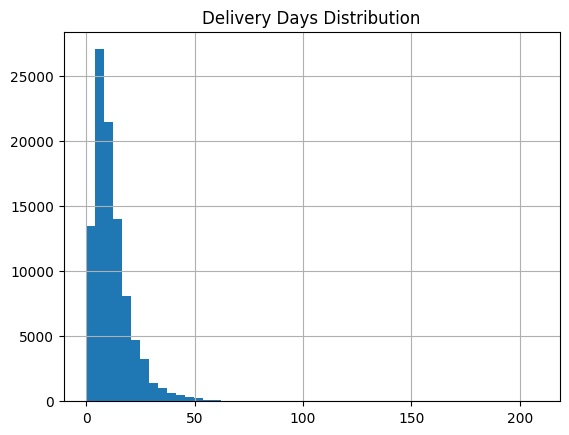

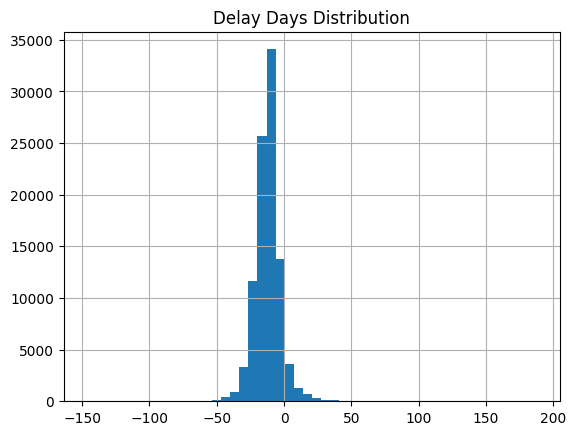

In [51]:
# distribution check
delievery_performance['delivery_days'].hist(bins=50)
plt.title("Delivery Days Distribution")
plt.show()

delievery_performance['delay_days'].hist(bins=50)
plt.title("Delay Days Distribution")
plt.show()

In [52]:
display(delievery_performance.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,negative_review,delivery_days,delay_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,False,8,-8,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,False,13,-6,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,False,9,-18,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5,False,13,-13,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5,False,2,-10,False


## Spatial features

Tables of interests
- orders
- order_items
- customers
- sellers

Features to be created

**Note:** One order has multiple sellers, use the first seller as the main seller for the order.

- same state # for one order_id, are seller and customer in the same state?
- shipping_distance # (optional if hard) for one order_id, how far is the seller from the customer? Use zip_code_prefix to do it
- seller_density # state_level: seller_density = number of sellers in a state

In [53]:
# Before start spatial feature engineering, map each order with only one seller
order_first_seller = (
    order_items[['order_id','seller_id']].
                      groupby('order_id',as_index=False).
                      first()
                      )
display(order_first_seller.head())

,order_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87


In [54]:
# merge `seller`, `orders`, `customers` to get spatial feature dataset
order_first_seller_geo = order_first_seller.merge(sellers, on='seller_id')
order_customer = orders[['order_id','customer_id']].merge(customers, on='customer_id')
# This is the spatial dataset we want
order_customer_seller = order_customer.merge(order_first_seller_geo, on='order_id')
print(order_customer_seller.shape)
display(order_customer_seller.head())

(96476, 10)


,order_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3504c0cb71d7fa48d967e0e4c94d59d9,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,289cdb325fb7e7f891c38608bf9e0962,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,66922902710d126a0e7d26b0e3805106,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2c9e548be18521d1c43cde1c582c6de8,8752,mogi das cruzes,SP


In [55]:
display(geolocation.head())

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [56]:
def haversine_distance(lat1, lon1, lat2, lon2):
  R = 6371.0  # km

  lat1 = np.radians(lat1)
  lon1 = np.radians(lon1)
  lat2 = np.radians(lat2)
  lon2 = np.radians(lon2)

  dlat = lat2 - lat1
  dlon = lon2 - lon1

  a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
  c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
  return R * c

# convert zipcode to geographic coordinate
def zipcode_to_geograph(zip_prefix):
  # Filter the geolocation DataFrame for the given zip_prefix
  filtered_geo = geolocation[geolocation['geolocation_zip_code_prefix'] == zip_prefix]
  if not filtered_geo.empty:
    # Take the mean lat/lon if multiple entries for the same zip prefix
    lat = filtered_geo['geolocation_lat'].mean()
    lon = filtered_geo['geolocation_lng'].mean()
    return lat, lon
  else:
    # Return NaN if no geolocation data found for the prefix
    return np.nan, np.nan

In [57]:
# same_state
order_customer_seller['same_state'] = (order_customer_seller['customer_state'] == order_customer_seller['seller_state'])

# Pre-process geolocation to get unique zip code prefix with mean lat/lon
geo_coords = geolocation.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat=('geolocation_lat', 'mean'),
    geolocation_lng=('geolocation_lng', 'mean')
).reset_index()

# Merge for customer coordinates
order_customer_seller = order_customer_seller.merge(
    geo_coords.rename(columns={
        'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
        'geolocation_lat': 'customer_lat',
        'geolocation_lng': 'customer_lon'
    }),
    left_on='customer_zip_code_prefix',
    right_on='customer_zip_code_prefix',
    how='left'
)

# Merge for seller coordinates
order_customer_seller = order_customer_seller.merge(
    geo_coords.rename(columns={
        'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
        'geolocation_lat': 'seller_lat',
        'geolocation_lng': 'seller_lon'
    }),
    left_on='seller_zip_code_prefix',
    right_on='seller_zip_code_prefix',
    how='left'
)

# shipping_distance
order_customer_seller['shipping_distance'] = haversine_distance(
    order_customer_seller['customer_lat'],
    order_customer_seller['customer_lon'],
    order_customer_seller['seller_lat'],
    order_customer_seller['seller_lon']
)

# seller_density
seller_density_map = (
    sellers
    .groupby('seller_state', as_index=False)
    .agg(seller_density=('seller_id', 'nunique'))
)

order_customer_seller = order_customer_seller.merge(
    seller_density_map,
    on='seller_state',
    how='left'
)

In [58]:
display(order_customer_seller.head())

,order_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_id,seller_zip_code_prefix,seller_city,seller_state,same_state,customer_lat,customer_lon,seller_lat,seller_lon,shipping_distance,seller_density
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3504c0cb71d7fa48d967e0e4c94d59d9,9350,maua,SP,True,-23.576983,-46.587161,-23.680729,-46.444238,18.576110,1849
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,289cdb325fb7e7f891c38608bf9e0962,31570,belo horizonte,SP,False,-12.177924,-44.660711,-19.807681,-43.980427,851.495069,1849
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,False,-16.745150,-48.514783,-21.363502,-48.229601,514.410666,1849
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,66922902710d126a0e7d26b0e3805106,31842,belo horizonte,MG,False,-5.774190,-35.271143,-19.837682,-43.924053,1822.226336,244
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2c9e548be18521d1c43cde1c582c6de8,8752,mogi das cruzes,SP,True,-23.676370,-46.514627,-23.543395,-46.262086,29.676625,1849


In [59]:
print(order_customer_seller[['shipping_distance']].isna().mean())

shipping_distance    0.004955
dtype: float64


## Order & Product Features

In [60]:
order_product = (
    order_items
    .groupby('order_id', as_index=False)
    .agg(
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        num_items=('order_item_id', 'count')
    )
)

order_product['freight_ratio'] = (
    order_product['total_freight'] / order_product['total_price']
)

print(order_product.shape)
print(order_product['order_id'].nunique())
display(order_product.head())

(98666, 5)
98666


,order_id,total_price,total_freight,num_items,freight_ratio
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,0.225637
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,0.083076
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,0.089799
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,0.090745


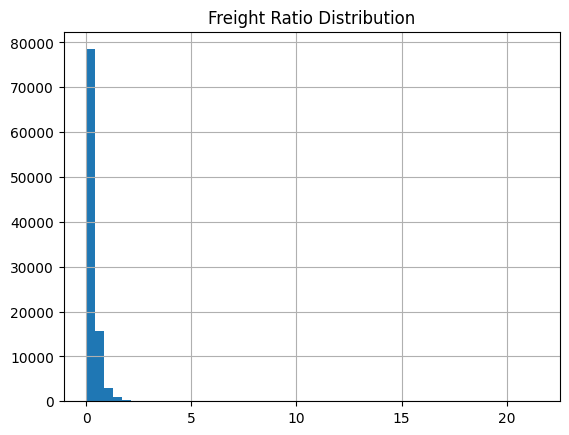

In [61]:
order_product['freight_ratio'].hist(bins=50)
plt.title("Freight Ratio Distribution")
plt.show()

# Final dataset generation

In [62]:
final_df = (
    delievery_performance
    .merge(
        order_customer_seller[
            ['order_id', 'same_state', 'shipping_distance', 'seller_density','customer_zip_code_prefix','customer_city','seller_state']
        ],
        on='order_id',
        how='inner'
    )
    .merge(
        order_product[
            ['order_id', 'total_price', 'freight_ratio', 'num_items']
        ],
        on='order_id',
        how='inner'
    )
)

print("Before dedup:", final_df.shape, final_df['order_id'].nunique())

final_df = final_df.drop_duplicates(subset='order_id')

print("After dedup:", final_df.shape, final_df['order_id'].nunique())

display(final_df.head())

Before dedup: (96359, 22) 95830
After dedup: (95830, 22) 95830


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,negative_review,...,late_delivery,same_state,shipping_distance,seller_density,customer_zip_code_prefix,customer_city,seller_state,total_price,freight_ratio,num_items
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,False,...,False,True,18.576110,1849,3149,sao paulo,SP,29.99,0.290764,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,False,...,False,False,851.495069,1849,47813,barreiras,SP,118.70,0.191744,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,False,...,False,False,514.410666,1849,75265,vianopolis,SP,159.90,0.120200,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5,False,...,False,False,1822.226336,244,59296,sao goncalo do amarante,MG,45.00,0.604444,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5,False,...,False,True,29.676625,1849,9195,santo andre,SP,19.90,0.438191,1


In [63]:
final_df = final_df.dropna()
final_df = final_df[final_df['total_price'] > 0]
final_df['same_state'] = final_df['same_state'].astype(int)
final_df['late_delivery'] = final_df['late_delivery'].astype(int)

print(final_df.shape)

(95338, 22)


In [64]:
display(final_df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,negative_review,...,late_delivery,same_state,shipping_distance,seller_density,customer_zip_code_prefix,customer_city,seller_state,total_price,freight_ratio,num_items
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,False,...,0,1,18.576110,1849,3149,sao paulo,SP,29.99,0.290764,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,False,...,0,0,851.495069,1849,47813,barreiras,SP,118.70,0.191744,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,False,...,0,0,514.410666,1849,75265,vianopolis,SP,159.90,0.120200,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5,False,...,0,0,1822.226336,244,59296,sao goncalo do amarante,MG,45.00,0.604444,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5,False,...,0,1,29.676625,1849,9195,santo andre,SP,19.90,0.438191,1


In [65]:
print("Final sample size:", len(final_df))
print("Retention rate:", len(final_df) / len(delievery_performance))

Final sample size: 95338
Retention rate: 0.9894042071835532


In [66]:
# final_df.to_csv('final_df.csv', index=False)

# Relevance check

We evaluate whether each feature is associated with negative_review:
```
1. Delivery performance
2. Spatial factors
3. Pricing & freight structure
```
Goal:

Identify which features have strong explanatory power for customer dissatisfaction.


In [67]:
# Baseline
# Overall negative review rate
print("Baseline negative review rate:", final_df['negative_review'].mean())

Baseline negative review rate: 0.12811260987224402


A simple logistic regression on features of interest

To isolate the effect of freight_ratio on negative reviews, we control for:

- total_price (log-transformed)
- shipping_distance (log-transformed)
- same_state (binary)
- seller_density

This allows us to test whether freight_ratio has an independent effect on customer dissatisfaction.

In [69]:
df = final_df.copy()
df['log_distance'] = np.log1p(df['shipping_distance'])
df['log_price'] = np.log1p(df['total_price'])

X = df[[
    'delay_days',
    'late_delivery',
    'freight_ratio',
    'log_price',
    'log_distance',
    'same_state',
    'seller_density'
]]

X = sm.add_constant(X)

y = df['negative_review']

# logistic regression
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.329030
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        negative_review   No. Observations:                95338
Model:                          Logit   Df Residuals:                    95330
Method:                           MLE   Df Model:                            7
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                  0.1404
Time:                        22:09:27   Log-Likelihood:                -31369.
converged:                       True   LL-Null:                       -36494.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -3.6762      0.107    -34.313      0.000      -3.886      -3.466
delay_days       

In [70]:
np.exp(model.params)

,0
const,0.025320
delay_days,1.013242
late_delivery,11.533389
freight_ratio,1.881517
log_price,1.356025
log_distance,0.981811
same_state,0.812293
seller_density,1.000132


## Key Interpretation of Regression

We interpret coefficients in terms of their effect on the likelihood of a negative review.

- **late_delivery**: positive and highly significant  
  → Orders that are delivered late are much more likely to receive negative reviews.  
  → This reflects direct service failure and is the strongest driver of dissatisfaction.

- **delay_days**: positive and significant  
  → Longer delays further increase the probability of complaints.  
  → This suggests that not only lateness, but the *severity of delay*, matters for customer experience.

- **freight_ratio**: positive and highly significant  
  → Higher shipping cost relative to product value increases complaint probability.  
  → Customers are sensitive to perceived unfair pricing, even after controlling for delivery performance.

- **log_price**: positive and significant  
  → Higher-priced orders are more likely to receive negative reviews.  
  → This may reflect higher expectations for more expensive purchases.

- **same_state**: negative and significant  
  → Orders within the same state are less likely to receive negative reviews.  
  → Cross-state logistics introduces additional operational risk.

- **seller_density**: positive and significant  
  → Regions with higher seller density are associated with more complaints.  
  → This may indicate congestion or inefficiencies in high-activity areas.

- **log_distance**: not significant  
  → Physical distance does not independently affect dissatisfaction once delivery performance and cost structure are controlled.

### Summary

Customer dissatisfaction is primarily driven by:

- **delivery performance** (late_delivery, delay_days) — direct service quality  
- **cost perception** (freight_ratio) — pricing fairness  
- **logistics structure** (same_state) — cross-region complexity  
- **operational environment** (seller_density) — regional congestion  

This indicates that delays and service execution issues are the core drivers, while pricing and logistics structure further amplify dissatisfaction.

# Final Model Definition

Based on the regression analysis, we retain only the key drivers of customer dissatisfaction:

- late_delivery
- delay_days
- freight_ratio
- log_price
- same_state
- seller_density

We exclude:
- log_distance (not independently significant)

This results in a simplified and interpretable model focused on the main behavioral and operational drivers.

The next model focuses on the most actionable variables and removes redundant features, improving interpretability without sacrificing explanatory power. And it is a decriptive model instead of the actual predictive modeling we will do in the next notebook.

In [71]:
df = final_df.copy()

df['log_price'] = np.log1p(df['total_price'])

X = df[['late_delivery','delay_days','freight_ratio', 'log_price', 'same_state', 'seller_density']]
X = sm.add_constant(X)

y = df['negative_review']

final_model = sm.Logit(y, X).fit()

print(final_model.summary())

Optimization terminated successfully.
         Current function value: 0.329042
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        negative_review   No. Observations:                95338
Model:                          Logit   Df Residuals:                    95331
Method:                           MLE   Df Model:                            6
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                  0.1404
Time:                        22:11:37   Log-Likelihood:                -31370.
converged:                       True   LL-Null:                       -36494.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -3.7740      0.086    -44.024      0.000      -3.942      -3.606
late_delivery    

### Implication

Although the overall explanatory power of the model is limited, the identified drivers are operationally controllable and point to clear priorities.

The results suggest that:

1. **Delivery performance is the primary lever**  
   - Reducing late deliveries and minimizing delay duration should have the largest impact on customer satisfaction.

2. **Shipping cost structure matters beyond delivery quality**  
   - Customers are sensitive to high freight cost relative to product value, even when delivery is completed successfully.

3. **Cross-state logistics introduces additional risk**  
   - Improving efficiency in cross-state fulfillment may reduce complaint rates.

4. **High seller-density regions may require operational attention**  
   - Congestion or coordination inefficiencies in these areas could contribute to poorer service outcomes.

Overall, improving execution quality (delivery reliability) should be prioritized, while pricing transparency and logistics structure optimization can further reduce dissatisfaction.